In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit


In [3]:
# Missing Values
from sklearn.impute import SimpleImputer

# Encoding
from sklearn.preprocessing import OneHotEncoder

# Scaling
from sklearn.preprocessing import StandardScaler

# Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Model
from sklearn.linear_model import LinearRegression

# Evaluation
from sklearn.metrics import mean_squared_error

# Save Model
import joblib

In [4]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [5]:
# Create a fake categorical feature

df["Income_Category"] = pd.cut(
    df["MedInc"],
    bins=[0,2,4,6,np.inf],
    labels=["Low","Medium","High","Very High"]
)

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal Income_Category  
0    -122.23        4.526       Very High  
1    -122.22        3.585       Very High  
2    -122.24        3.521       Very High  
3    -122.25        3.413            High  
4    -122.25        3.422          Medium  


In [6]:
train_set, test_set = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

print("Train:",len(train_set))
print("Test :",len(test_set))

Train: 16512
Test : 4128


In [7]:
split = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_index,test_index in split.split(df,df["Income_Category"]):
    strat_train = df.loc[train_index]
    strat_test = df.loc[test_index]

print(strat_train["Income_Category"].value_counts(normalize=True))
print(strat_test["Income_Category"].value_counts(normalize=True))

Income_Category
Medium       0.489159
High         0.277374
Low          0.119004
Very High    0.114462
Name: proportion, dtype: float64
Income_Category
Medium       0.489099
High         0.277374
Low          0.119186
Very High    0.114341
Name: proportion, dtype: float64


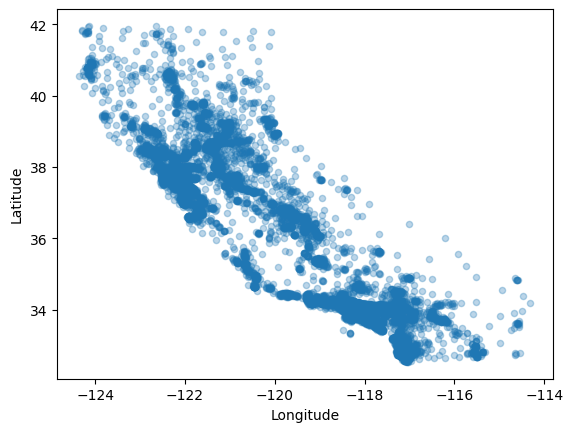

In [8]:
import matplotlib.pyplot as plt

df.plot(
    kind="scatter",
    x="Longitude",
    y="Latitude",
    alpha=0.3
)

plt.show()

In [10]:
df_missing = strat_train.copy()

df_missing.loc[0:100,"HouseAge"] = np.nan

imputer = SimpleImputer(strategy="median")

numeric_data = df_missing.drop(
    ["Income_Category"],
    axis=1
)

imputer.fit(numeric_data)

filled_data = imputer.transform(numeric_data)

filled_df = pd.DataFrame(
    filled_data,
    columns=numeric_data.columns
)

print(filled_df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [11]:
encoder = OneHotEncoder()

income_cat = df_missing[["Income_Category"]]

encoded = encoder.fit_transform(income_cat)

print(encoded.toarray())

print(encoder.categories_)

[[0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 ...
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]]
[array(['High', 'Low', 'Medium', 'Very High'], dtype=object)]


In [12]:
scaler = StandardScaler()

scaled = scaler.fit_transform(filled_df)

print(scaled[:5])

[[-0.46783798 -0.76861906 -0.06408085  0.32946524 -0.78734287 -0.02180595
   1.21699687 -0.60609455 -1.01051228]
 [-1.22604061  1.85846392 -0.17359623 -0.22489889 -0.98913865  0.00437972
   1.91302115 -1.12926142 -0.05875009]
 [-0.87406328  1.46042105 -0.05505016 -0.27410171 -0.55798909 -0.06330001
   2.44554979 -2.24036818 -0.93409341]
 [ 0.93795641  0.50511815  0.05576409 -0.19776094 -0.1081712   0.06682115
  -0.82436292  0.84382503 -0.13777414]
 [-1.01729696  0.82355245 -0.66695543 -0.23760255  1.05104328  0.0444412
   0.86664908 -0.6359898  -1.13208774]]


In [14]:
num_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

In [15]:
housing_num = strat_train.drop(
    ["Income_Category"],
    axis=1
)

prepared_num = num_pipeline.fit_transform(housing_num)

print(prepared_num.shape)

(16512, 9)


In [16]:
num_attribs = housing_num.columns.tolist()

cat_attribs = ["Income_Category"]

full_pipeline = ColumnTransformer([
    ("num",num_pipeline,num_attribs),
    ("cat",OneHotEncoder(),cat_attribs)
])

housing_prepared = full_pipeline.fit_transform(strat_train)

print(housing_prepared.shape)


(16512, 13)


In [ ]:
housing_labels = strat_train["MedHouseVal"].copy()
housing_prepared = full_pipeline.transform(strat_train)